# KNN - Nada

In [20]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
!pip install eli5 lime shap
import eli5
from eli5.sklearn import PermutationImportance
from sklearn.inspection import PartialDependenceDisplay
from lime import lime_tabular
import shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 9.0 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=26b5f21fa6da8681e09f9a25c389825ebec5fb39748465ce9946ed3400622f5a
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [21]:
x = data.drop(columns=["stroke_risk_percentage"])
y = data["stroke_risk_percentage"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

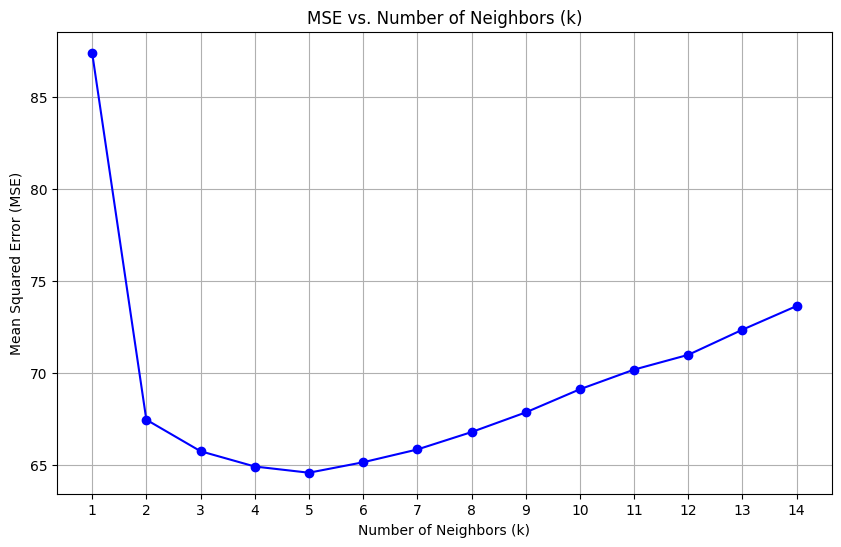

In [25]:
k_values = range(1, 15)
mse_list = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(x_train, y_train)
    knn_pred = knn.predict(x_test)

    MSE = mean_squared_error(y_test, knn_pred)
    mse_list.append(MSE)

plt.figure(figsize=(10, 6))
plt.plot(k_values, mse_list, marker='o', linestyle='-', color='b')
plt.xticks(k_values)
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('MSE vs. Number of Neighbors (k)')
plt.grid()
plt.show()

In [22]:
knn = KNeighborsRegressor(n_neighbors=5)

history = knn.fit(x_train, y_train)

In [32]:
predictions = knn.predict(x_test)

In [40]:
MSE = mean_squared_error(y_test, predictions)

MAE = mean_absolute_error(y_test, predictions)

R2 = r2_score(y_test, predictions)

print(f"Mean Squared Error: {MSE}")
print(f'Mean Absolute Error (MAE): {MAE}')
print(f'R-squared (R2): {R2}')

Mean Squared Error: 64.58057874745649
Mean Absolute Error (MAE): 5.865410354962695
R-squared (R2): 0.9325924977951258


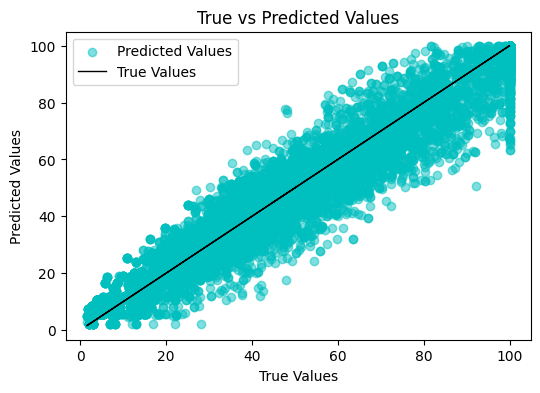

In [41]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(y_test, predictions, c="c", alpha=0.5, label="Predicted Values")

ax.plot(y_test, y_test, c="k", lw=1, label="True Values")

ax.set_xlabel('True Values')
ax.set_ylabel('Predicted Values')
ax.set_title('True vs Predicted Values')
ax.legend()

In [60]:
#Seeing which data points affect the prediction / are nearest to the test point

examples = get_examples(x_test, y_test)

for i, j in zip(range(5), examples.keys()):
  distances, indices = knn.kneighbors(examples[j].values.reshape(1, -1))

  print(f"Test point {i+1}: Prediction: {str(knn.predict(x_test.iloc[[j]]))}, Actual: {str(y_test.iloc[j])}")

  n_data = x_train.iloc[indices[0]]
  n_target = y_train.iloc[indices[0]]

  print("Nearest neighbors values:")
  print(n_target, "\n")

Test point 1: Prediction: [2.78], Actual: 1.5
Nearest neighbors values:
15678    7.2
28756    1.5
3462     2.2
26401    1.5
30919    1.5
Name: stroke_risk_percentage, dtype: float64 

Test point 2: Prediction: [27.86], Actual: 25.7
Nearest neighbors values:
27370    33.6
34957    25.7
33738    23.6
30232    20.7
33597    35.7
Name: stroke_risk_percentage, dtype: float64 

Test point 3: Prediction: [52.3], Actual: 50.3
Nearest neighbors values:
15776    50.3
19122    50.3
19122    50.3
17470    50.3
24170    60.3
Name: stroke_risk_percentage, dtype: float64 

Test point 4: Prediction: [68.14], Actual: 77.1
Nearest neighbors values:
4384     54.7
27471    54.7
19061    77.1
19061    77.1
19061    77.1
Name: stroke_risk_percentage, dtype: float64 

Test point 5: Prediction: [88.44], Actual: 100.0
Nearest neighbors values:
30076    100.0
16203     77.8
17263     96.6
31585    100.0
27156     67.8
Name: stroke_risk_percentage, dtype: float64 



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


In [59]:
# Seeing which data points affect the prediction / are nearest to the test point
# Nearest neighbors' data for the first test point vs its data

distances, indices = knn.kneighbors(examples[8193].values.reshape(1, -1))

print(f"Test point {1}: Prediction: {str(knn.predict(x_test.iloc[[8193]]))}, Actual: {str(y_test.iloc[8193])}")

n_data = x_train.iloc[indices[0]]
n_target = y_train.iloc[indices[0]]

print("Nearest neighbors values:")
print(n_target, "\n")

print("Test point's data:")
print(x_test.iloc[8193], "\n")

print("Nearest neighbours' data:")
print(n_data)

Test point 1: Prediction: [2.78], Actual: 1.5
Nearest neighbors values:
15678    7.2
28756    1.5
3462     2.2
26401    1.5
30919    1.5
Name: stroke_risk_percentage, dtype: float64 

Test point's data:
age                    18
chest_pain              0
high_blood_pressure     0
irregular_heartbeat     0
shortness_of_breath     0
fatigue_weakness        0
dizziness               0
neck_jaw_pain           0
chest_discomfort        0
snoring_sleep_apnea     0
Name: 11512, dtype: int64 

Nearest neighbours' data:
       age  chest_pain  high_blood_pressure  irregular_heartbeat  \
15678   18           0                    0                    0   
28756   18           0                    0                    0   
3462    18           0                    0                    0   
26401   18           0                    0                    0   
30919   18           0                    0                    0   

       shortness_of_breath  fatigue_weakness  dizziness  neck_jaw_pain  \


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


In [67]:
# Seeing which data points affect the prediction / are nearest to the test point
# Nearest neighbors' data for the third test point vs its data

distances, indices = knn.kneighbors(examples[1797].values.reshape(1, -1))

print(f"Test point {3}: Prediction: {str(knn.predict(x_test.iloc[[1797]]))}, Actual: {str(y_test.iloc[1797])}")

n_data = x_train.iloc[indices[0]]
n_target = y_train.iloc[indices[0]]

print("Nearest neighbors values:")
print(n_target, "\n")

print("Test point's data:")
print(x_test.iloc[1797], "\n")

print("Nearest neighbours' data:")
print(n_data)

Test point 3: Prediction: [52.3], Actual: 50.3
Nearest neighbors values:
15776    50.3
19122    50.3
19122    50.3
17470    50.3
24170    60.3
Name: stroke_risk_percentage, dtype: float64 

Test point's data:
age                    50
chest_pain              0
high_blood_pressure     0
irregular_heartbeat     0
shortness_of_breath     0
fatigue_weakness        0
dizziness               0
neck_jaw_pain           1
chest_discomfort        0
snoring_sleep_apnea     0
Name: 15776, dtype: int64 

Nearest neighbours' data:
       age  chest_pain  high_blood_pressure  irregular_heartbeat  \
15776   50           0                    0                    0   
19122   50           0                    0                    0   
19122   50           0                    0                    0   
17470   50           0                    0                    0   
24170   50           0                    0                    0   

       shortness_of_breath  fatigue_weakness  dizziness  neck_jaw_pa

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


In [43]:
perm = PermutationImportance(knn, random_state=0).fit(x_test, y_test)
display(eli5.show_weights(perm, feature_names=x.columns.tolist()))

Weight,Feature
0.9905 ± 0.0067,age
0.1299 ± 0.0035,high_blood_pressure
0.0755 ± 0.0029,chest_pain
0.0569 ± 0.0015,shortness_of_breath
0.0443 ± 0.0012,snoring_sleep_apnea
0.0440 ± 0.0022,chest_discomfort
0.0343 ± 0.0009,fatigue_weakness
0.0307 ± 0.0019,irregular_heartbeat
0.0287 ± 0.0007,dizziness
0.0141 ± 0.0011,neck_jaw_pain


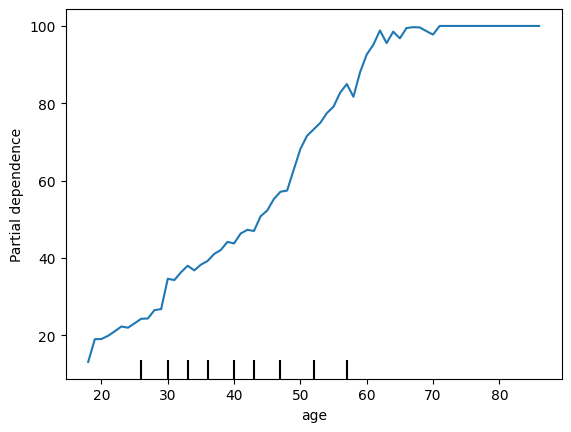

In [49]:
PartialDependenceDisplay.from_estimator(knn, x, features=[0])

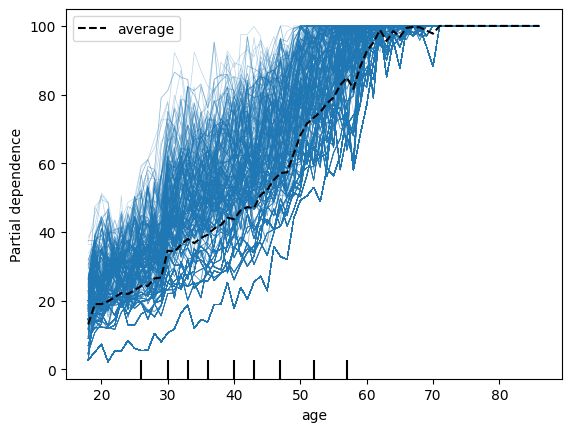

In [50]:
PartialDependenceDisplay.from_estimator(knn, x, features=[0], kind="both", pd_line_kw={'color': 'black'})

<Axes: xlabel='importance', ylabel='feature'>

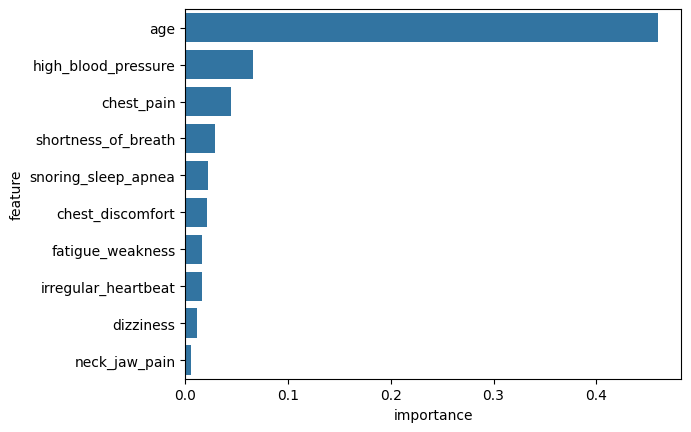

In [51]:
importance = []

knn2 = KNeighborsRegressor(n_neighbors=5)

for col in x.columns:
  x_col_removed = x.drop(columns=[col])
  x_train2, x_test2, y_train2, y_test2 = train_test_split(x_col_removed, y, test_size=0.2, random_state=0)

  history2 = knn2.fit(x_train2, y_train2)

  predictions2 = knn2.predict(x_test2)
  R2_cols_rem = r2_score(y_test2, predictions2)

  difference = R2 - R2_cols_rem
  importance.append({"feature": col, "importance": difference})

res_df = pd.DataFrame(importance)
res_df = res_df.sort_values(by="importance", ascending=False)

sns.barplot(data=res_df, x="importance", y="feature")

/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

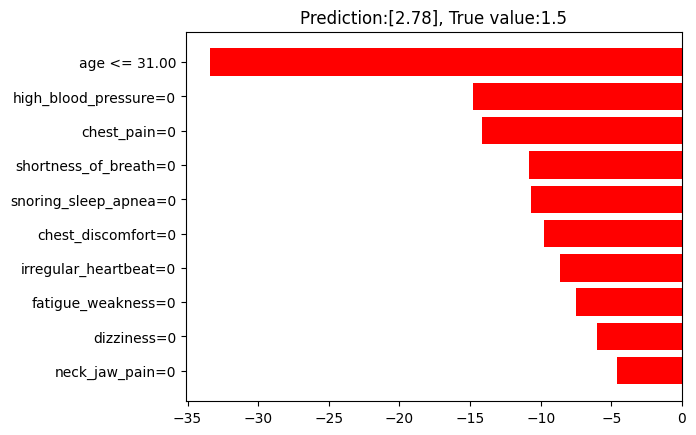

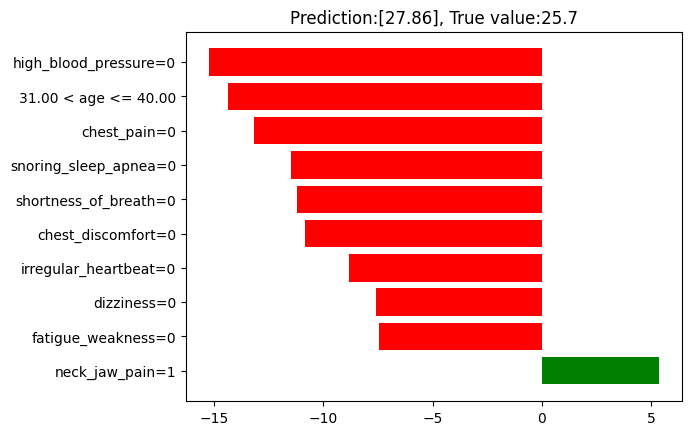

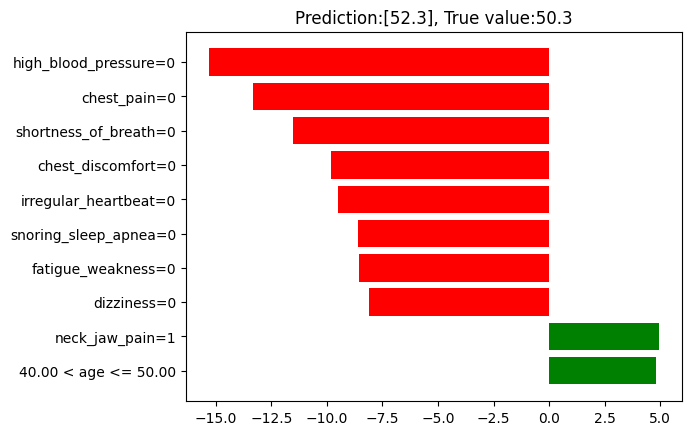

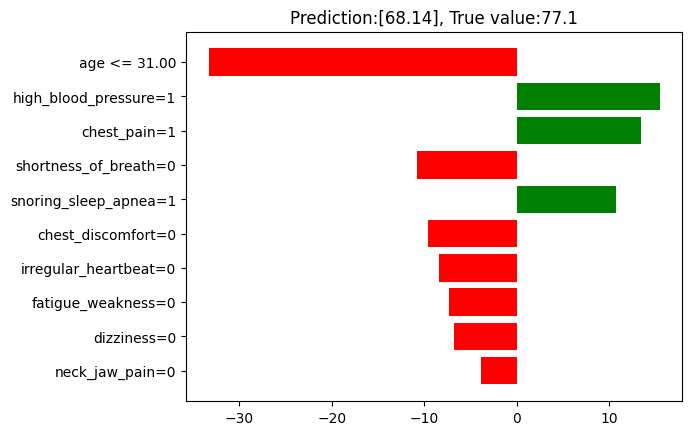

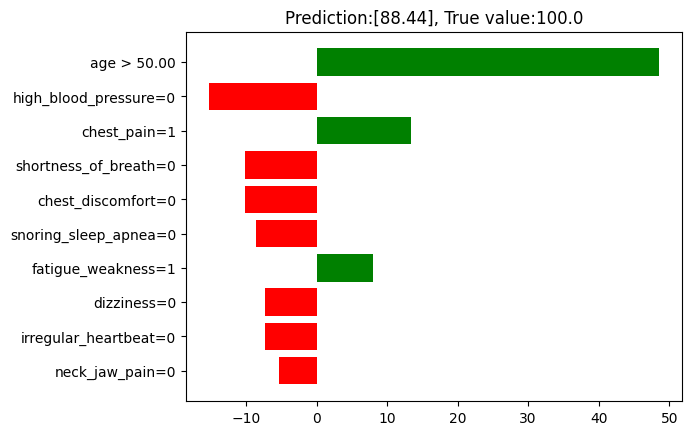

In [53]:
explainer = lime_tabular.LimeTabularExplainer(training_data=x_train.to_numpy(), feature_names=x.columns, categorical_features=[1,2,3,4,5,6,7,8,9], mode="regression")

def model_predict(data):
  return knn.predict(data)

def get_examples(x_test, y_test):
  examples = {}
  ranges = [0,25,50,75,100]
  percentiles = np.percentile(y_test,ranges)
  for p in percentiles:
    index = np.argmin(np.abs(y_test - p))
    examples[index] = x_test.iloc[index]

  return examples

examples = get_examples(x_test, y_test)

for i, item in examples.items():
    explanation = explainer.explain_instance(
        data_row=item,
        predict_fn=model_predict,
        num_features=10
    )

    explanation.as_pyplot_figure()
    plt.title("Prediction:" + str(knn.predict(x_test.iloc[[i]])) + ", True value:" + str(y_test.iloc[i]))

In [61]:
def get_examples_shap(x_test, y_test):
  examples = []
  ranges = [0,25,50,75,100]
  percentiles = np.percentile(y_test,ranges)
  for p in percentiles:
    index = np.argmin(np.abs(y_test - p))
    examples.append(x_test.iloc[index])

  return examples

examples2 = get_examples_shap(x_test, y_test)

background = x_train.iloc[np.random.choice(x_train.shape[0], 100, replace=False)]
explainer = shap.KernelExplainer(model_predict, background)

shap_values = explainer.shap_values(pd.DataFrame(examples2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


  0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12

In [79]:
shap.initjs()
for i in range(5):
  display(shap.force_plot(
      explainer.expected_value,
      shap_values[i],
      examples2[i]
  ))

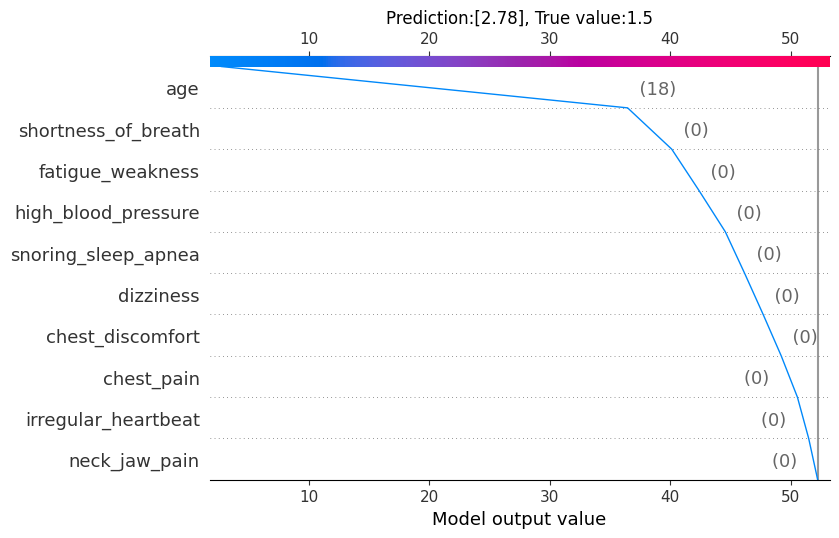

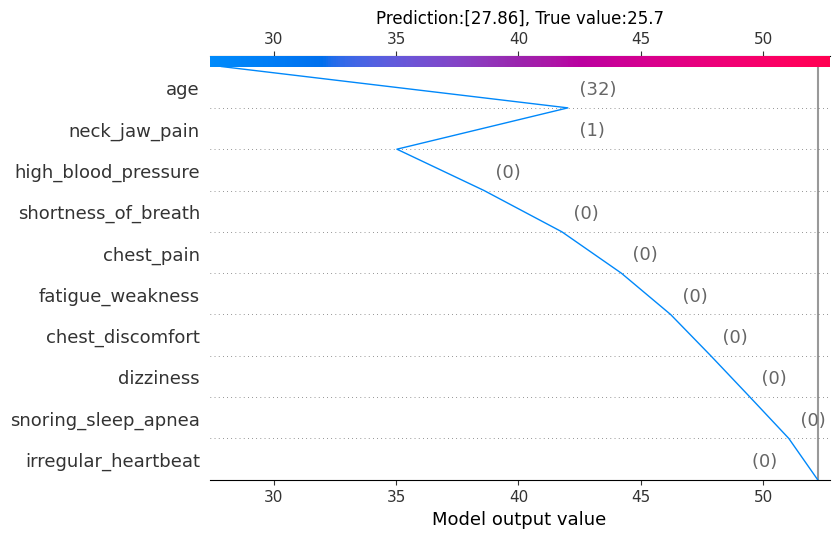

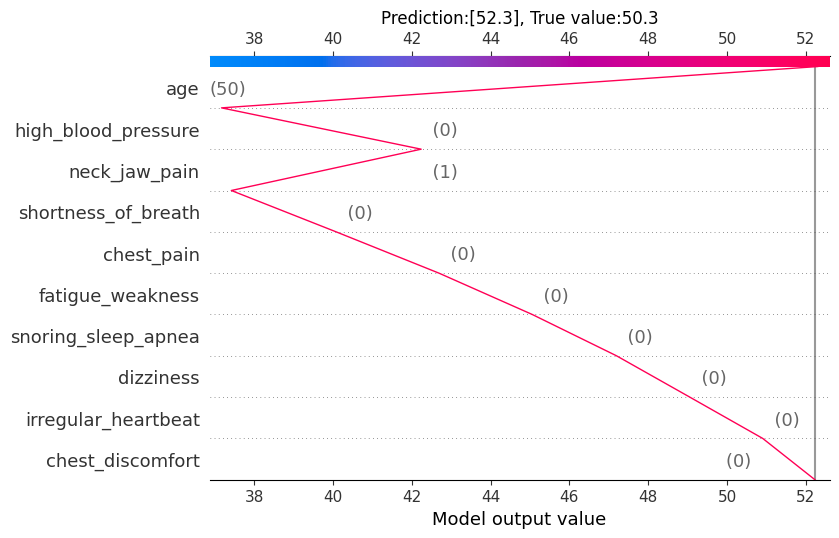

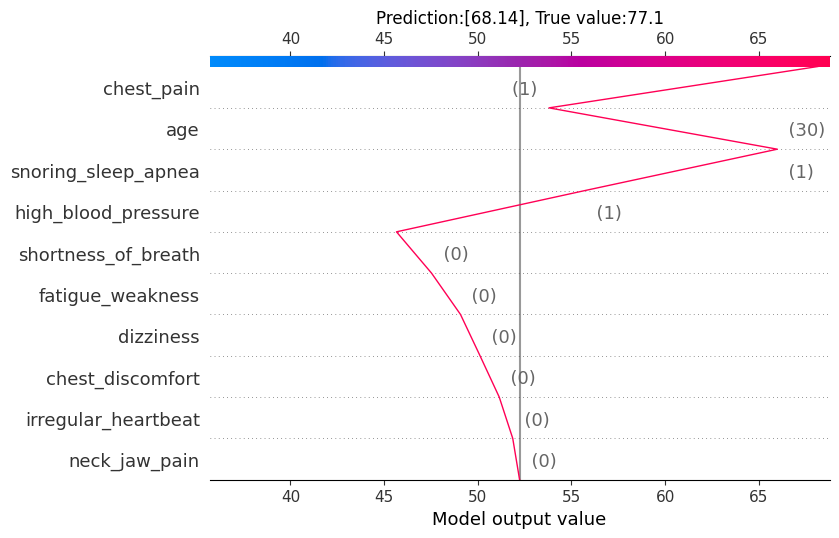

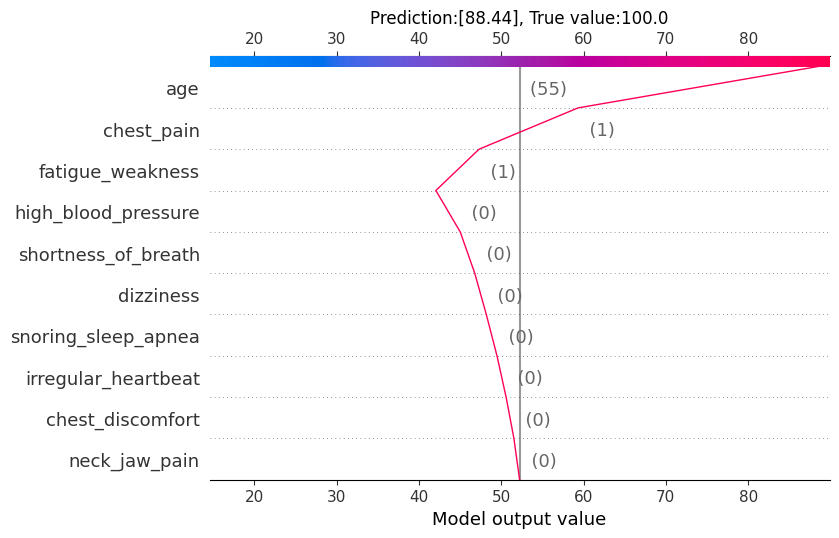

In [71]:
for i, j in zip(range(5), examples.keys()):
  shap.decision_plot(
      explainer.expected_value,
      shap_values[i],
      examples2[i],
      show=False
  )
  plt.title("Prediction:" + str(knn.predict(x_test.iloc[[j]])) + ", True value:" + str(y_test.iloc[j]))
  plt.show()

  0%|          | 0/500 [00:00<?, ?it/s]

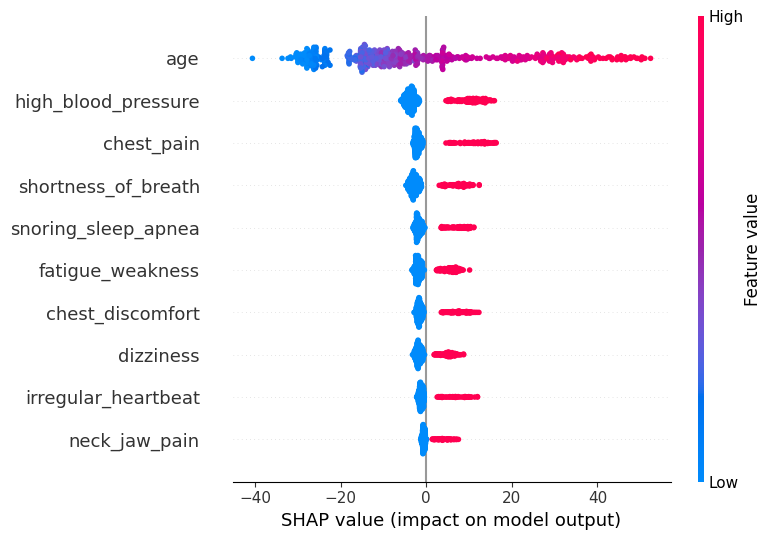

In [82]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    x_test_sample = x_test.sample(500, random_state=0)
    shap_values2 = explainer.shap_values(x_test_sample)
    shap.summary_plot(shap_values2, x_test_sample)